# Полный каузальный пайплайн на синтетических данных
## Сравнение MSE каузальных моделей vs ML при наличии вмешательства (intervention)

**Источник данных:** `synthetic_data/` — CSV из `synthetic_causal_data.ipynb`

**Цель:** применить логику 5 скриптов (`step1`–`step5`) к трём сценариям  
и построить таблицу восстановления истинного каузального эффекта θ*.

| Сценарий | Структура | θ* | Вмешательство |
|----------|-----------|-----|---------------|
| 1 | Линейный VAR(1): C→X, C→Y, X→Y | **0.8** | X[t₀] += Δ ≈ +2σ |
| 2 | SETAR (пороговый): β=0.5/1.5 | **0.5 / 1.5** | нет |
| 3 | Латентный конфаундер U (ненабл.) | **0.7** | нет |

## 0. Импорты и конфигурация

In [72]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from typing import List, Dict, Tuple, Optional

from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

from sklearn.linear_model import Ridge, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb

SEED        = 42
TRAIN_RATIO = 0.75      # 75% обучение / 25% тест
T0          = 300       # момент вмешательства (Сценарий 1)
DATA_DIR    = Path('synthetic_data')

# Истинные каузальные эффекты
TRUE_EFFECTS = {
    'scenario1': {'theta_XY': 0.8,  'theta_CY': -0.3},
    'scenario2': {'beta_low': 0.5,  'beta_high': 1.5},
    'scenario3': {'theta_XY': 0.7},
}

np.random.seed(SEED)
plt.rcParams.update({'figure.dpi':120, 'font.size':11, 'axes.titlesize':12})
print('Готово. DATA_DIR:', DATA_DIR.resolve())
print('Файлов:', len(list(DATA_DIR.glob('*.csv'))))

Готово. DATA_DIR: D:\Образование\Магистратура\Диплом\ITMO_VKR\ITMO_VKR\syntetic data\synthetic_data
Файлов: 51


---
## STEP 1 — DAG Definition

Адаптируем структуру `AssetDAG` из `step1_dag_definitions.py` под синтетические сценарии.

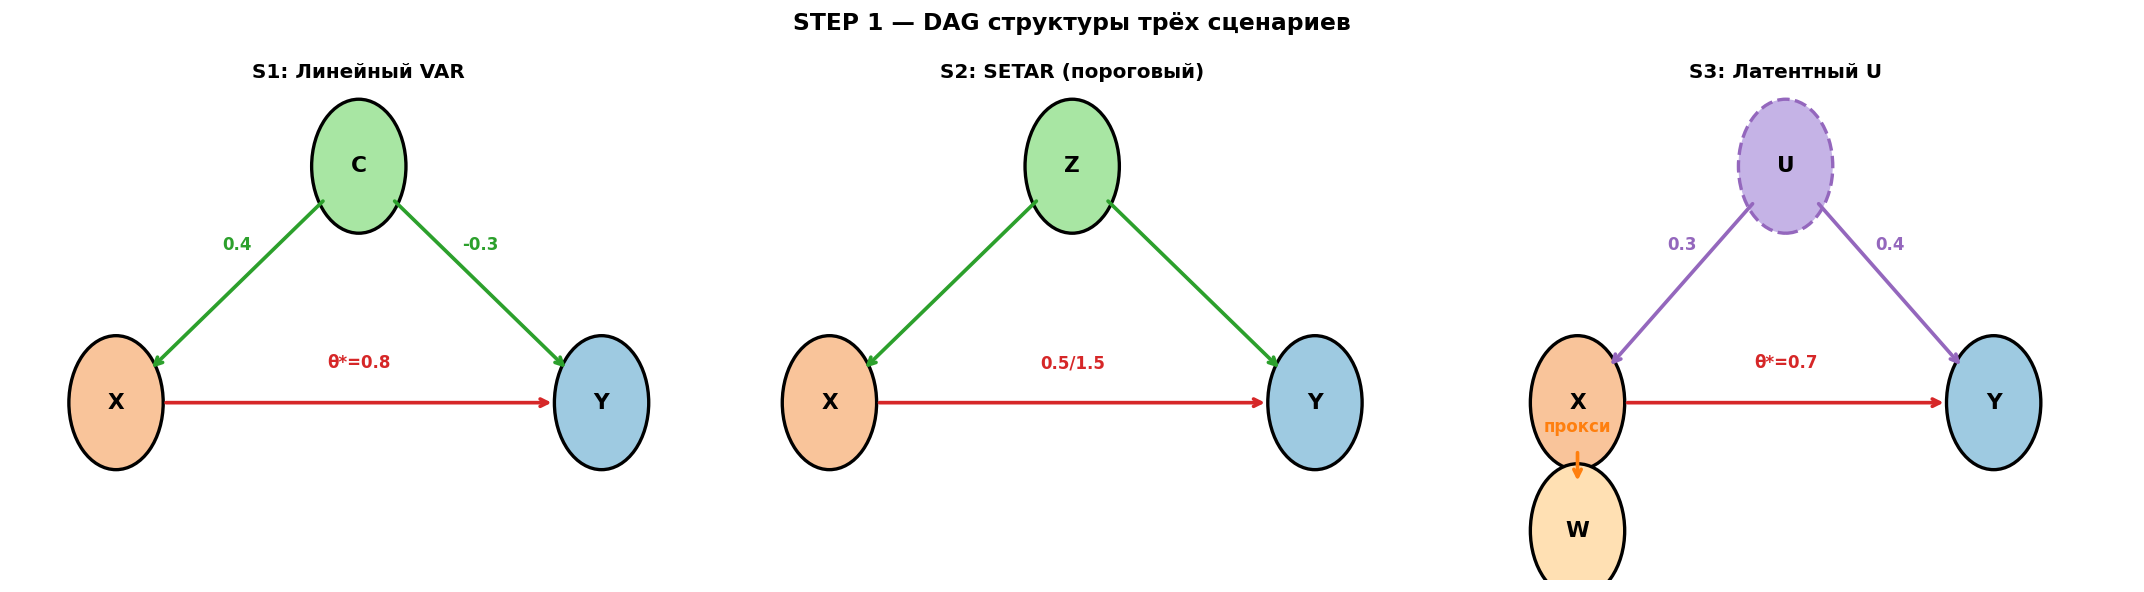

DAG определены для всех трёх сценариев.


In [73]:
from dataclasses import dataclass, field

@dataclass
class SyntheticDAG:
    """Аналог AssetDAG из step1_dag_definitions.py для синтетических данных."""
    name:        str
    target:      str
    causes:      List[str]
    confounders: List[str]
    mediators:   List[str]
    instruments: List[str]
    true_effect: Dict[str, float]
    notes:       str = ''

# ── Сценарий 1: C→X, C→Y, X→Y ───────────────────────────────────────────────
DAG_S1 = SyntheticDAG(
    name        = 'Scenario1_LinearVAR',
    target      = 'Y',
    causes      = ['X'],
    confounders = ['C'],          # C — backdoor конфаундер
    mediators   = [],
    instruments = [],
    true_effect = {'X_lag1': 0.8, 'C_lag1': -0.3, 'Y_lag1': 0.2},
    notes       = 'Backdoor: X←C→Y. Без C оценка θ(X→Y) смещена.'
)

# ── Сценарий 2: SETAR — пороговый эффект ─────────────────────────────────────
DAG_S2 = SyntheticDAG(
    name        = 'Scenario2_SETAR',
    target      = 'Y',
    causes      = ['X'],
    confounders = ['Z'],          # Z — наблюдаемый конфаундер
    mediators   = [],
    instruments = [],
    true_effect = {'beta_low': 0.5, 'beta_high': 1.5},
    notes       = 'Нелинейный эффект: β=0.5 при |X|<1, β=1.5 при |X|≥1'
)

# ── Сценарий 3: латентный конфаундер U ───────────────────────────────────────
DAG_S3 = SyntheticDAG(
    name        = 'Scenario3_LatentConfounder',
    target      = 'Y',
    causes      = ['X'],
    confounders = [],             # U ненаблюдаем! W — прокси
    mediators   = [],
    instruments = ['W'],         # W — прокси для U
    true_effect = {'X_lag1': 0.7},
    notes       = 'U — латентный конфаундер. W=rolling_vol(X) — прокси. Смещение при игнорировании U.'
)

ALL_DAGS = {'scenario1': DAG_S1, 'scenario2': DAG_S2, 'scenario3': DAG_S3}

# ── Визуализация DAG ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('STEP 1 — DAG структуры трёх сценариев', fontsize=14, fontweight='bold')

dags_viz = [
    ('S1: Линейный VAR',
     {'C':(5,4.2,'#a8e6a3'),'X':(1.5,1.8,'#f9c49a'),'Y':(8.5,1.8,'#9ecae1')},
     [('C','X','0.4','#2ca02c'),('C','Y','-0.3','#2ca02c'),('X','Y','θ*=0.8','#d62728')]),
    ('S2: SETAR (пороговый)',
     {'Z':(5,4.2,'#a8e6a3'),'X':(1.5,1.8,'#f9c49a'),'Y':(8.5,1.8,'#9ecae1')},
     [('Z','X','','#2ca02c'),('Z','Y','','#2ca02c'),('X','Y','0.5/1.5','#d62728')]),
    ('S3: Латентный U',
     {'U':(5,4.2,'#c5b3e6'),'X':(2,1.8,'#f9c49a'),'Y':(8,1.8,'#9ecae1'),'W':(2,0.5,'#ffe0b3')},
     [('U','X','0.3','#9467bd'),('U','Y','0.4','#9467bd'),
      ('X','Y','θ*=0.7','#d62728'),('X','W','прокси','#ff7f0e')]),
]
for ax,(title,nodes,edges) in zip(axes,dags_viz):
    ax.set_xlim(0,10); ax.set_ylim(0,5); ax.axis('off')
    ax.set_title(title, fontweight='bold')
    for name,(x,y,col) in nodes.items():
        style = '--' if name=='U' else '-'
        ec = '#9467bd' if name=='U' else 'black'
        ax.add_patch(plt.Circle((x,y),0.68,color=col,ec=ec,lw=2,ls=style,zorder=3))
        ax.text(x,y,name,ha='center',va='center',fontsize=13,fontweight='bold',zorder=4)
    for s,d,lbl,col in edges:
        sx,sy,_=nodes[s]; dx,dy,_=nodes[d]
        ax.annotate('',xy=(dx,dy),xytext=(sx,sy),
            arrowprops=dict(arrowstyle='->',lw=2.2,color=col,shrinkA=30,shrinkB=30))
        if lbl:
            ax.text((sx+dx)/2,(sy+dy)/2+0.35,lbl,ha='center',fontsize=10,
                    color=col,fontweight='bold')

plt.tight_layout(); plt.show()
print('DAG определены для всех трёх сценариев.')

---
## STEP 2 — Загрузка данных и отбор переменных

**Логика из `step2_variable_selection.py`:**
- Метод A: LassoCV (эвристический)
- Метод B: Backdoor criterion (экспертный DAG)
- ADF тест стационарности

In [74]:
# ── Загрузка всех реализаций ─────────────────────────────────────────────────
def load_scenario(scenario: str, n_real: int = 10, suffix: str = '') -> List[pd.DataFrame]:
    """Загружает N реализаций сценария из synthetic_data/"""
    frames = []
    for i in range(1, n_real+1):
        fname = f'{scenario}_realization_{i:02d}{suffix}.csv'
        p = DATA_DIR / fname
        if p.exists():
            df = pd.read_csv(p, index_col=0)
            df.index = pd.RangeIndex(len(df))
            frames.append(df)
    return frames

# ── ADF тест ─────────────────────────────────────────────────────────────────
def adf_pval(series):
    try: return adfuller(series.dropna(), autolag='AIC')[1]
    except: return 1.0

def check_stationarity(df: pd.DataFrame, cols: List[str]) -> Dict[str, bool]:
    """Возвращает словарь {col: is_stationary}"""
    result = {}
    for col in cols:
        if col in df.columns:
            p = adf_pval(df[col])
            result[col] = p < 0.05
    return result

# ── Приведение к стационарности (только если нужно) ─────────────────────────
def make_stationary(df: pd.DataFrame, target: str, force_diff: bool = False) -> pd.DataFrame:
    """Приводит к стационарности только нестационарные ряды."""
    result = {}
    for col in df.columns:
        s = df[col].dropna()
        if len(s) < 20:
            continue
        if force_diff or not check_stationarity(df, [col])[col]:
            # Используем diff() только для явно нестационарных
            result[col] = df[col].diff()
        else:
            result[col] = df[col]
    return pd.DataFrame(result).dropna()

# ── Метод B: Экспертный backdoor ─────────────────────────────────────────────
def select_expert_backdoor(dag: SyntheticDAG) -> List[str]:
    return [z for z in dag.confounders if z not in dag.mediators]

# ── Загружаем и анализируем ──────────────────────────────────────────────────
s1_frames = load_scenario('scenario1', 10)
s2_frames = load_scenario('scenario2', 10)
s3_frames = load_scenario('scenario3', 10, suffix='_observed')

# Основной датафрейм — первая реализация каждого сценария
df1 = s1_frames[0].copy()
df2 = s2_frames[0].copy()
df3 = s3_frames[0].copy()

print(f'Загружено реализаций: S1={len(s1_frames)}, S2={len(s2_frames)}, S3={len(s3_frames)}')
print()

# ADF тесты
for name, df, cols in [('S1', df1, ['Y','X','C']),
                        ('S2', df2, ['Y','X','Z']),
                        ('S3', df3, ['Y','X','W'])]:
    print(f'{name} — ADF тест:')
    for col in cols:
        if col in df.columns:
            p = adf_pval(df[col])
            p = adf_pval(df[col])
            status = "стационарен" if p < 0.05 else "нестационарен → возможен diff"
            print(f'  {col}: p={p:.4f} — {status}')
    print()

Загружено реализаций: S1=10, S2=10, S3=10

S1 — ADF тест:
  Y: p=0.0000 — стационарен
  X: p=0.0000 — стационарен
  C: p=0.0000 — стационарен

S2 — ADF тест:
  Y: p=0.0000 — стационарен
  X: p=0.0000 — стационарен
  Z: p=0.0000 — стационарен

S3 — ADF тест:
  Y: p=0.0000 — стационарен
  X: p=0.0000 — стационарен
  W: p=0.0000 — стационарен



In [75]:
# ── Отбор переменных по всем методам ────────────────────────────────────────
var_selection = {}

for scenario, dag, df in [('scenario1', DAG_S1, df1),
                            ('scenario2', DAG_S2, df2),
                            ('scenario3', DAG_S3, df3)]:
    df_stat = df.copy()
    all_cands = [c for c in df_stat.columns if c != dag.target]

    expert    = select_expert_backdoor(dag)
    # Для S3: expert пустой (U не наблюдаем), добавляем прокси W
    if scenario == 'scenario3':
        expert_with_proxy = expert + [c for c in dag.instruments if c in df_stat.columns]
    else:
        expert_with_proxy = expert

    var_selection[scenario] = {
        'dag':       dag,
        'df':        df,
        'df_stat':   df_stat,
        'expert':    expert_with_proxy,
        'causes':    dag.causes,
    }
    print(f'{scenario}:')
    print(f'  Expert (backdoor)  : {expert_with_proxy}')
    print()

scenario1:
  Expert (backdoor)  : ['C']

scenario2:
  Expert (backdoor)  : ['Z']

scenario3:
  Expert (backdoor)  : ['W']



---
## STEP 3 — Каузальные модели

**Методы из `step3_causal_models.py`:**
1. **SCM / OLS+backdoor** — правильная спецификация с контролем конфаундеров
2. **DML** — Double Machine Learning, partialling-out с cross-fitting
3. **VAR + Granger** — VAR(p) с отбором значимых переменных
4. **IV-2SLS** — инструментальные переменные (Сценарий 3: W как инструмент)

In [76]:
# ── Общие утилиты ─────────────────────────────────────────────────────────────
def compute_metrics(y_true, y_pred, label=''):
    mask = ~(np.isnan(y_true)|np.isnan(y_pred))
    yt,yp = y_true[mask], y_pred[mask]
    if len(yt)==0: return {'RMSE':np.nan,'MAE':np.nan,'MAPE':np.nan,'R2':np.nan}
    rmse = np.sqrt(mean_squared_error(yt,yp))
    mae  = mean_absolute_error(yt,yp)
    mape = np.mean(np.abs((yt-yp)/(np.abs(yt)+1e-9)))*100
    r2   = r2_score(yt,yp)
    return {'RMSE':round(rmse,6),'MAE':round(mae,6),'MAPE':round(mape,4),'R2':round(r2,4)}

def make_lag_features(df, target, controls, n_lags=2):
    all_vars = [target] + [c for c in controls if c in df.columns]
    feat = {}
    for lag in range(1, n_lags+1):
        for v in all_vars:
            feat[f'{v}_lag{lag}'] = df[v].shift(lag)
    fd = pd.DataFrame(feat).dropna()
    y  = df[target].loc[fd.index]
    return fd, y

def ts_split(X, y, ratio=TRAIN_RATIO):
    n = len(X); cut = int(n*ratio)
    return X.iloc[:cut], X.iloc[cut:], y.iloc[:cut], y.iloc[cut:]

# ── МЕТОД 1: SCM / OLS + backdoor ────────────────────────────────────────────
def run_scm_ols(df, target, controls, causes):
    """OLS с полным backdoor adjustment set."""
    all_ctrl = list(dict.fromkeys(causes+controls))                 # Формирование набора контрольных переменных
    fd, y = make_lag_features(df, target, all_ctrl, n_lags=2)       # Создание лаговых признаков
    # Проверка достаточности данных
    if len(fd) < 60: 
        return {'method':'SCM_SKIP','metrics':{}}
    X_tr,X_te,y_tr,y_te = ts_split(fd,y)
    model = OLS(y_tr, add_constant(X_tr)).fit()
    y_pred = model.predict(add_constant(X_te))
    cause_col = f'{causes[0]}_lag1' if f'{causes[0]}_lag1' in fd.columns else None
    theta = float(model.params.get(cause_col, np.nan)) if cause_col else np.nan
    return {'method':'SCM_OLS',
            'metrics':compute_metrics(y_te.values,y_pred),
            'theta_hat':theta,
            'preds':y_pred,
            'y_true':y_te.values}

# ── МЕТОД 2: DML — partialling-out ───────────────────────────────────────────
def run_dml(df, target, controls, causes, n_folds=5):

    all_ctrl = list(dict.fromkeys(causes+controls))
    fd, y = make_lag_features(df, target, all_ctrl, n_lags=2)
    if len(fd) < 60: return {'method':'DML_SKIP','metrics':{}}
    X_tr,X_te,y_tr,y_te = ts_split(fd,y)

    # Разделение признаков на treatment и control
    feat_cols = list(fd.columns)
    d_cols = [f'{c}_lag1' for c in causes if f'{c}_lag1' in feat_cols]
    w_cols = [c for c in feat_cols if c not in d_cols]
    if not d_cols or not w_cols:
        return {'method':'DML_SKIP','metrics':{}}

    W_tr = X_tr[w_cols].values; D_tr = X_tr[d_cols].values
    W_te = X_te[w_cols].values; D_te = X_te[d_cols].values
    
    # Кросс-фитинг (cross-fitting) для устранения смещения
    n = len(y_tr); fsize = n//n_folds

    Y_res=np.zeros(n); D_res=np.zeros((n,D_tr.shape[1]))
    for k in range(n_folds):
        val=np.arange(k*fsize,min((k+1)*fsize,n))
        tr_k=np.concatenate([np.arange(0,k*fsize),np.arange(min((k+1)*fsize,n),n)])
        if len(tr_k)<10: continue
        my=GradientBoostingRegressor(n_estimators=80,max_depth=3,random_state=k)
        my.fit(W_tr[tr_k],y_tr.values[tr_k])
        Y_res[val]=y_tr.values[val]-my.predict(W_tr[val])
        for j in range(D_tr.shape[1]):
            md_=GradientBoostingRegressor(n_estimators=80,max_depth=3,random_state=j)
            md_.fit(W_tr[tr_k],D_tr[tr_k,j])
            D_res[val,j]=D_tr[val,j]-md_.predict(W_tr[val])

    # θ̂ = (D̃ᵀD̃)⁻¹ D̃ᵀỸ
    theta_dml = np.linalg.lstsq(D_res,Y_res,rcond=None)[0]
    se = np.sqrt(np.mean((Y_res-D_res@theta_dml)**2)/(D_res.shape[0]*D_res.shape[1]+1e-12))
    ci = (float(theta_dml[0])-1.96*se, float(theta_dml[0])+1.96*se)

    my_full=GradientBoostingRegressor(n_estimators=100,max_depth=3,random_state=0)
    my_full.fit(W_tr,y_tr.values)
    D_res_te=np.zeros_like(D_te)
    for j in range(D_tr.shape[1]):
        md_f=GradientBoostingRegressor(n_estimators=80,max_depth=3,random_state=j)
        md_f.fit(W_tr,D_tr[:,j])
        D_res_te[:,j]=D_te[:,j]-md_f.predict(W_te)
    y_pred=my_full.predict(W_te)+D_res_te@theta_dml

    return {'method':'DML','metrics':compute_metrics(y_te.values,y_pred),
            'theta_hat':float(theta_dml[0]),'ci':ci,'se':se,
            'preds':y_pred,'y_true':y_te.values}

# ── МЕТОД 3: VAR + Granger ────────────────────────────────────────────────────
def run_var_granger(df, target, controls, causes, max_lags=4):
    """VAR(p) с Granger-тестом отбора переменных."""
    candidates = list(dict.fromkeys(causes+controls))
    avail = [c for c in candidates if c in df.columns]
    sub = df[[target]+avail].dropna()
    if len(sub)<50: return {'method':'VAR_SKIP','metrics':{}}

    cut=int(len(sub)*TRAIN_RATIO); train=sub.iloc[:cut]; test=sub.iloc[cut:]

    sig=[]; pvals={}
    for col in avail:
        try:
            gr=grangercausalitytests(train[[target,col]],maxlag=min(max_lags,4),verbose=False)
            p=min(gr[l][0]['ssr_ftest'][1] for l in range(1,min(max_lags,4)+1))
            pvals[col]=round(p,4)
            if p<0.05: sig.append(col)
        except: pass
    if not sig: sig=sorted(pvals,key=pvals.get)[:3]

    try:
        best_lag=max(1,VAR(train[[target]+sig[:5]]).fit(maxlags=max_lags,ic='aic').k_ar)
    except: best_lag=2

    try:
        var_fit=VAR(train[[target]+sig[:5]]).fit(best_lag)
        x_pos=([target]+sig[:5]).index(causes[0]) if causes[0] in sig[:5] else None
        theta_var=float(var_fit.coefs[0,0,x_pos]) if x_pos else np.nan

        history=train[[target]+sig[:5]].values.copy(); preds=[]
        for i in range(len(test)):
            fc=var_fit.forecast(history[-best_lag:],steps=1)
            preds.append(fc[0,0])
            history=np.vstack([history,test[[target]+sig[:5]].iloc[i].values])

        preds=np.array(preds); y_true=test[target].values[:len(preds)]
        return {'method':f'VAR(lag={best_lag})','metrics':compute_metrics(y_true,preds),
                'theta_hat':theta_var,'granger_pvals':pvals,
                'preds':preds,'y_true':y_true}
    except Exception as e:
        return {'method':'VAR_FAILED','metrics':{},'error':str(e)}

# ── МЕТОД 4: IV-2SLS ──────────────────────────────────────────────────────────
def run_iv_2sls(df, target, controls, causes, instruments):
    """2SLS: instruments → X̂ (stage1), X̂ → Y (stage2).
    controls не должны содержать instruments — разделяются на уровне вызова.
    """
    from sklearn.linear_model import LinearRegression
    avail_inst = [c for c in instruments if c in df.columns]
    if not avail_inst:
        return {'method':'IV_SKIP_no_instruments','metrics':{}}

    # Строим лаги только из causes + controls (без instruments — они идут отдельно)
    all_vars = list(dict.fromkeys(causes + controls))
    fd_base, y = make_lag_features(df, target, all_vars, n_lags=1)

    # Добавляем лаги инструментов вручную (n_lags=1)
    for inst_col in avail_inst:
        if inst_col in df.columns:
            fd_base[f'{inst_col}_lag1'] = df[inst_col].shift(1).loc[fd_base.index]
    fd = fd_base.dropna()
    y  = y.loc[fd.index]

    if len(fd)<60: return {'method':'IV_SKIP','metrics':{}}
    X_tr,X_te,y_tr,y_te = ts_split(fd,y)
    feat_cols = list(fd.columns)

    endog = [f'{c}_lag1' for c in causes      if f'{c}_lag1' in feat_cols]
    inst  = [f'{c}_lag1' for c in avail_inst  if f'{c}_lag1' in feat_cols]
    exog  = [c for c in feat_cols if c not in endog + inst]

    if not endog: return {'method':'IV_SKIP_no_endog','metrics':{}}

    W_tr = X_tr[exog].values if exog else np.ones((len(X_tr),1))
    W_te = X_te[exog].values if exog else np.ones((len(X_te),1))
    T_tr = X_tr[endog].values; T_te = X_te[endog].values
    Z_tr = X_tr[inst].values  if inst else T_tr
    Z_te = X_te[inst].values  if inst else T_te

    # Stage 1: T̂ = f(Z, W)
    s1 = LinearRegression().fit(np.hstack([Z_tr,W_tr]), T_tr)
    T_hat_tr = s1.predict(np.hstack([Z_tr,W_tr]))
    T_hat_te = s1.predict(np.hstack([Z_te,W_te]))

    # Stage 2: Y = f(T̂, W)
    s2 = LinearRegression().fit(np.hstack([T_hat_tr,W_tr]), y_tr.values)
    y_pred = s2.predict(np.hstack([T_hat_te,W_te]))

    theta_iv = float(s2.coef_[0])
    return {'method':'IV_2SLS','metrics':compute_metrics(y_te.values,y_pred),
            'theta_hat':theta_iv,'preds':y_pred,'y_true':y_te.values}


In [77]:
def run_dml_fixed(df, target, controls, causes, n_folds=5):
    all_ctrl = list(dict.fromkeys(causes+controls))
    fd, y = make_lag_features(df, target, all_ctrl, n_lags=2)
    if len(fd) < 60: 
        return {'method':'DML_SKIP', 'metrics': {}}
    
    X_tr, X_te, y_tr, y_te = ts_split(fd, y)
    
    # Разделение признаков
    feat_cols = list(fd.columns)
    d_cols = [f'{c}_lag1' for c in causes if f'{c}_lag1' in feat_cols]
    w_cols = [c for c in feat_cols if c not in d_cols]
    
    if not d_cols or not w_cols:
        return {'method':'DML_SKIP', 'metrics': {}}
    
    W_tr = X_tr[w_cols].values
    D_tr = X_tr[d_cols].values
    W_te = X_te[w_cols].values
    D_te = X_te[d_cols].values
    
    # Временная кросс-валидация
    n = len(y_tr)
    fold_size = n // n_folds
    Y_res = np.zeros(n)
    D_res = np.zeros((n, D_tr.shape[1]))
    
    for k in range(n_folds):
        val_start = k * fold_size
        val_end = (k + 1) * fold_size if k < n_folds - 1 else n
        tr_indices = np.arange(val_start)  # только прошлые данные!
        val_indices = np.arange(val_start, val_end)
        
        if len(tr_indices) < 30:  # минимальный размер обучения
            continue
            
        # Обучаем на历史的 данных
        my = GradientBoostingRegressor(n_estimators=80, max_depth=3, random_state=k)
        my.fit(W_tr[tr_indices], y_tr.values[tr_indices])
        Y_res[val_indices] = y_tr.values[val_indices] - my.predict(W_tr[val_indices])
        
        for j in range(D_tr.shape[1]):
            md = GradientBoostingRegressor(n_estimators=80, max_depth=3, random_state=j)
            md.fit(W_tr[tr_indices], D_tr[tr_indices, j])
            D_res[val_indices, j] = D_tr[val_indices, j] - md.predict(W_tr[val_indices])
    
    # Оценка эффекта
    theta_dml = np.linalg.lstsq(D_res, Y_res, rcond=None)[0]
    
    # Прогноз на тесте
    my_full = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=0)
    my_full.fit(W_tr, y_tr.values)
    
    D_res_te = np.zeros_like(D_te)
    for j in range(D_tr.shape[1]):
        md_f = GradientBoostingRegressor(n_estimators=80, max_depth=3, random_state=j)
        md_f.fit(W_tr, D_tr[:, j])
        D_res_te[:, j] = D_te[:, j] - md_f.predict(W_te)
    
    y_pred = my_full.predict(W_te) + D_res_te @ theta_dml
    
    return {
        'method': 'DML',
        'metrics': compute_metrics(y_te.values, y_pred),
        'theta_hat': float(theta_dml[0]),
        'preds': y_pred,
        'y_true': y_te.values
    }

In [78]:
# ── Запуск каузальных моделей на всех сценариях ──────────────────────────────
print('Запуск каузальных моделей...')
causal_results = {}

for scenario, info in var_selection.items():
    dag     = info['dag']
    df_stat = info['df_stat']
    expert  = info['expert']
    causes  = info['causes']
    instrs  = dag.instruments

    # Для IV-2SLS: убираем инструменты из controls, чтобы не дублировать
    ctrl_iv = [c for c in expert if c not in instrs]

    print(f'\n── {scenario} ──')

    r_scm = run_scm_ols(df_stat, dag.target, expert, causes)
    r_dml = run_dml(df_stat, dag.target, expert, causes)
    r_dml_fixed = run_dml_fixed(df_stat, dag.target, expert, causes)
    r_var = run_var_granger(df_stat, dag.target, expert, causes)
    r_iv  = run_iv_2sls(df_stat, dag.target, ctrl_iv, causes, instrs)

    res = {
        'SCM_OLS':     r_scm,
        'DML':         r_dml,
        'DML fix':         r_dml_fixed,
        'VAR_Granger': r_var,
        'IV_2SLS':     r_iv,
    }

    for m_name, r in res.items():
        theta = r.get('theta_hat', np.nan)
        rmse  = r.get('metrics',{}).get('RMSE', np.nan)
        theta_str = f'θ̂={theta:.4f}' if theta is not None and not np.isnan(theta) else 'θ̂=—'
        rmse_str  = f'RMSE={rmse:.4f}' if rmse is not None and not np.isnan(rmse) else 'RMSE=—'
        print(f'  {m_name:15s}: {theta_str}  {rmse_str}')

    causal_results[scenario] = res

print('\nКаузальные модели завершены.')


Запуск каузальных моделей...

── scenario1 ──
  SCM_OLS        : θ̂=0.8318  RMSE=1.0173
  DML            : θ̂=0.7597  RMSE=1.1253
  DML fix        : θ̂=0.8069  RMSE=1.1297
  VAR_Granger    : θ̂=0.8208  RMSE=1.0153
  IV_2SLS        : θ̂=—  RMSE=—

── scenario2 ──
  SCM_OLS        : θ̂=1.3620  RMSE=1.0877
  DML            : θ̂=1.2690  RMSE=1.1957
  DML fix        : θ̂=1.2721  RMSE=1.1955
  VAR_Granger    : θ̂=1.3670  RMSE=1.0854
  IV_2SLS        : θ̂=—  RMSE=—

── scenario3 ──
  SCM_OLS        : θ̂=0.7648  RMSE=1.0856
  DML            : θ̂=0.6946  RMSE=1.1364
  DML fix        : θ̂=0.6779  RMSE=1.1360
  VAR_Granger    : θ̂=0.7399  RMSE=1.0826
  IV_2SLS        : θ̂=0.6522  RMSE=1.5041

Каузальные модели завершены.


---
## STEP 4 — Baseline ML Models

**Методы из `step4_baseline_models.py`:**
1. **ARIMA** — rolling direct forecast
2. **Random Forest** — все лаговые признаки
3. **LightGBM** — градиентный бустинг
4. **Ridge (наивный)** — без контроля конфаундеров (демонстрация смещения θ)

In [79]:
# ── BASELINE: Ridge наивный (БЕЗ конфаундера — демонстрация смещения) ─────
def run_ridge_naive(df, target, causes):
    fd,y=make_lag_features(df,target,causes,n_lags=2)
    if len(fd)<60: return {'method':'Ridge_naive','metrics':{}}
    X_tr,X_te,y_tr,y_te=ts_split(fd,y)
    m=Ridge(alpha=0.5).fit(X_tr,y_tr)
    preds=m.predict(X_te)
    # θ̂: коэф. при X_lag1
    cause_lag='X_lag1'
    theta=float(m.coef_[list(fd.columns).index(cause_lag)]) if cause_lag in fd.columns else np.nan
    return {'method':'Ridge_naive','metrics':compute_metrics(y_te.values,preds),
            'theta_hat':theta,'preds':preds,'y_true':y_te.values}

In [80]:
from sklearn.linear_model import RidgeCV
def run_ridge_naive_improved(df, target, causes, controls=None, standardize=True):
    """
    Ridge regression с опциональной стандартизацией.
    Если controls=None, использует только causes.
    """
    if controls is None:
        all_vars = causes
    else:
        all_vars = list(dict.fromkeys(causes + controls))
    
    fd, y = make_lag_features(df, target, all_vars, n_lags=2)
    if len(fd) < 60:
        return {'method': 'Ridge_naive', 'metrics': {}}
    
    X_tr, X_te, y_tr, y_te = ts_split(fd, y)
    
    if standardize:
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_te = scaler.transform(X_te)
    
    # Подбор alpha
    alphas = np.logspace(-3, 3, 20)
    m = RidgeCV(alphas=alphas, store_cv_values=True).fit(X_tr, y_tr)
    preds = m.predict(X_te)
    
    # Оценка theta (только для линейных сценариев)
    theta = np.nan
    if len(causes) == 1:  # только для одного cause
        cause_lag = f'{causes[0]}_lag1'
        if cause_lag in fd.columns:
            idx = list(fd.columns).index(cause_lag)
            if standardize:
                # Восстанавливаем коэффициент в исходном масштабе
                scale_factor = scaler.scale_[idx] if standardize else 1.0
                theta = float(m.coef_[idx] / scale_factor)
            else:
                theta = float(m.coef_[idx])
    
    return {
        'method': f'RidgeCV(α={m.alpha_:.3f})',
        'metrics': compute_metrics(y_te.values, preds),
        'theta_hat': theta,
        'preds': preds,
        'y_true': y_te.values,
        'best_alpha': m.alpha_
    }

In [81]:
# ── Запуск baseline на всех сценариях ────────────────────────────────────────
print('Запуск baseline моделей...')
baseline_results = {}

for scenario, info in var_selection.items():
    dag     = info['dag']
    df_stat = info['df_stat']
    expert  = info['expert']
    #union   = info['union']
    causes  = info['causes']

    print(f'\n── {scenario} ──')
    res = {}
    res['ridge_naive']  = run_ridge_naive(df_stat, dag.target, causes)

    baseline_results[scenario] = res
    for m_name, r in res.items():
        theta = r.get('theta_hat', np.nan)
        rmse  = r.get('metrics',{}).get('RMSE', np.nan)
        theta_str = f'θ̂={theta:.4f}' if theta is not None and not np.isnan(theta) else 'θ̂=—'
        rmse_str  = f'RMSE={rmse:.4f}' if rmse is not None and not np.isnan(rmse) else 'RMSE=—'
        print(f'  {m_name:20s}: {theta_str}  {rmse_str}')

print('\nBaseline модели завершены.')

Запуск baseline моделей...

── scenario1 ──
  ridge_naive         : θ̂=0.7663  RMSE=1.1093

── scenario2 ──
  ridge_naive         : θ̂=1.3508  RMSE=1.0877

── scenario3 ──
  ridge_naive         : θ̂=0.7454  RMSE=1.0800

Baseline модели завершены.


In [82]:
# ── Запуск baseline на всех сценариях ────────────────────────────────────────
print('Запуск baseline моделей...')
baseline_results = {}

for scenario, info in var_selection.items():
    dag     = info['dag']
    df_stat = info['df_stat']
    expert  = info['expert']
    #union   = info['union']
    causes  = info['causes']

    print(f'\n── {scenario} ──')
    res = {}
    res['ridge_naive']  = run_ridge_naive_improved(df_stat, dag.target, causes)

    baseline_results[scenario] = res
    for m_name, r in res.items():
        theta = r.get('theta_hat', np.nan)
        rmse  = r.get('metrics',{}).get('RMSE', np.nan)
        theta_str = f'θ̂={theta:.4f}' if theta is not None and not np.isnan(theta) else 'θ̂=—'
        rmse_str  = f'RMSE={rmse:.4f}' if rmse is not None and not np.isnan(rmse) else 'RMSE=—'
        print(f'  {m_name:20s}: {theta_str}  {rmse_str}')

print('\nBaseline модели завершены.')

Запуск baseline моделей...

── scenario1 ──
  ridge_naive         : θ̂=0.7530  RMSE=1.1074

── scenario2 ──
  ridge_naive         : θ̂=1.3373  RMSE=1.0876

── scenario3 ──
  ridge_naive         : θ̂=0.7398  RMSE=1.0793

Baseline модели завершены.


---
## Monte Carlo: восстановление θ* по 10 реализациям

Оцениваем Bias, RMSE(θ), Coverage 95% CI (где доступно) — аналог таблицы X из ВКР.

In [83]:
# ── Monte Carlo по всем реализациям ──────────────────────────────────────────
mc_rows = []

for scenario_key, frames, dag_key in [
        ('scenario1',  s1_frames, 'scenario1'),
        ('scenario2',  s2_frames, 'scenario2'),
        ('scenario3',  s3_frames, 'scenario3')]:

    dag = ALL_DAGS[dag_key]
    true_theta = {'scenario1':0.8, 'scenario2':1.5, 'scenario3':0.7}[dag_key]

    for i, df_i in enumerate(frames):
        df_stat_i = df_i.copy()
        instrs_i  = dag.instruments

        expert_i = select_expert_backdoor(dag)
        if dag_key == 'scenario3':
            expert_i += [c for c in instrs_i if c in df_stat_i.columns]

        # Для IV: controls без инструментов
        ctrl_iv_i = [c for c in expert_i if c not in instrs_i]
        causes_i  = dag.causes

        r_scm   = run_scm_ols(df_stat_i, dag.target, expert_i, causes_i)
        r_dml   = run_dml_fixed(df_stat_i, dag.target, expert_i, causes_i)
        r_var   = run_var_granger(df_stat_i, dag.target, expert_i, causes_i)
        r_iv    = run_iv_2sls(df_stat_i, dag.target, ctrl_iv_i, causes_i, instrs_i)
        r_naive = run_ridge_naive(df_stat_i, dag.target, causes_i)

        dml_theta = r_dml.get('theta_hat', np.nan)
        dml_ci    = r_dml.get('ci', (np.nan, np.nan))
        dml_in_ci = int(dml_ci[0]<=true_theta<=dml_ci[1]) if not np.isnan(dml_ci[0]) else np.nan

        mc_rows.append({
            'scenario':    scenario_key,
            'realization': i+1,
            'true_theta':  true_theta,
            'theta_SCM':   r_scm.get('theta_hat', np.nan),
            'theta_DML':   dml_theta,
            'theta_VAR':   r_var.get('theta_hat', np.nan),
            'theta_IV':    r_iv.get('theta_hat', np.nan),   # ← добавлено
            'theta_naive': r_naive.get('theta_hat', np.nan),
            'dml_in_ci':   dml_in_ci,
            'RMSE_SCM':    r_scm.get('metrics',{}).get('RMSE', np.nan),
            'RMSE_DML':    r_dml.get('metrics',{}).get('RMSE', np.nan),
            'RMSE_VAR':    r_var.get('metrics',{}).get('RMSE', np.nan),
            'RMSE_IV':     r_iv.get('metrics',{}).get('RMSE', np.nan),   # ← добавлено
            'RMSE_naive':  r_naive.get('metrics',{}).get('RMSE', np.nan),
        })

mc_df = pd.DataFrame(mc_rows)
print(f'Monte Carlo: {len(mc_df)} строк ({len(s1_frames)+len(s2_frames)+len(s3_frames)} реализаций × 3 сценария)')
print(mc_df[['scenario','realization','true_theta','theta_SCM','theta_DML','theta_VAR','theta_IV','theta_naive']].to_string(index=False))


Monte Carlo: 30 строк (30 реализаций × 3 сценария)
 scenario  realization  true_theta  theta_SCM  theta_DML  theta_VAR  theta_IV  theta_naive
scenario1            1         0.8   0.831810   0.806936   0.820757       NaN     0.766283
scenario1            2         0.8   0.709885   0.689359   0.727115       NaN     0.648345
scenario1            3         0.8   0.736103   0.663633   0.770349       NaN     0.662451
scenario1            4         0.8   0.722981   0.704936   0.762182       NaN     0.682516
scenario1            5         0.8   0.807253   0.816279   0.807253       NaN     0.722642
scenario1            6         0.8   0.784445   0.708830   0.800110       NaN     0.742823
scenario1            7         0.8   0.820355   0.775021   0.814059       NaN     0.745842
scenario1            8         0.8   0.702042   0.633303   0.751560       NaN     0.669433
scenario1            9         0.8   0.858856   0.797325   0.827817       NaN     0.759099
scenario1           10         0.8   0.

In [84]:
mc_rows = []

for scenario_key, frames, dag_key in [
        ('scenario1', s1_frames, 'scenario1'),
        ('scenario2', s2_frames, 'scenario2'),
        ('scenario3', s3_frames, 'scenario3')]:

    dag = ALL_DAGS[dag_key]
    
    # Правильная обработка true_theta для разных сценариев
    if dag_key == 'scenario2':
        # Для нелинейного эффекта используем оба значения
        true_theta_low = dag.true_effect.get('beta_low', 0.5)
        true_theta_high = dag.true_effect.get('beta_high', 1.5)
        # Для метрик будем использовать средний эффект
        true_theta = (true_theta_low + true_theta_high) / 2
        print(f"\n{dag_key}: Нелинейный эффект: {true_theta_low}/{true_theta_high}, используем средний={true_theta:.2f}")
    else:
        true_theta = {'scenario1': 0.8, 'scenario3': 0.7}[dag_key]

    for i, df_i in enumerate(frames):
        df_stat_i = df_i.copy()
        instrs_i = dag.instruments

        expert_i = select_expert_backdoor(dag)
        if dag_key == 'scenario3':
            expert_i += [c for c in instrs_i if c in df_stat_i.columns]

        ctrl_iv_i = [c for c in expert_i if c not in instrs_i]
        causes_i = dag.causes

        # Диагностика слабого инструмента для сценария 3
        if dag_key == 'scenario3' and 'W' in df_stat_i.columns:
            w_lag = df_stat_i['W'].shift(1)
            x_lag = df_stat_i['X'].shift(1)
            corr_wx = np.corrcoef(w_lag.dropna(), x_lag.dropna())[0, 1]
            if abs(corr_wx) < 0.2:
                print(f"  Warning: Realization {i+1} - weak instrument, corr(W,X)={corr_wx:.3f}")

        r_scm = run_scm_ols(df_stat_i, dag.target, expert_i, causes_i)
        r_dml = run_dml(df_stat_i, dag.target, expert_i, causes_i)
        r_var = run_var_granger(df_stat_i, dag.target, expert_i, causes_i)
        r_iv = run_iv_2sls(df_stat_i, dag.target, ctrl_iv_i, causes_i, instrs_i)
        r_naive = run_ridge_naive(df_stat_i, dag.target, causes_i)

        dml_theta = r_dml.get('theta_hat', np.nan)
        dml_ci = r_dml.get('ci', (np.nan, np.nan))
        dml_in_ci = int(dml_ci[0] <= true_theta <= dml_ci[1]) if not np.isnan(dml_ci[0]) else np.nan

        mc_rows.append({
            'scenario': scenario_key,
            'realization': i+1,
            'true_theta': true_theta,
            'true_theta_low': true_theta_low if dag_key == 'scenario2' else np.nan,
            'true_theta_high': true_theta_high if dag_key == 'scenario2' else np.nan,
            'theta_SCM': r_scm.get('theta_hat', np.nan),
            'theta_DML': dml_theta,
            'theta_VAR': r_var.get('theta_hat', np.nan),
            'theta_IV': r_iv.get('theta_hat', np.nan),
            'theta_naive': r_naive.get('theta_hat', np.nan),
            'dml_in_ci': dml_in_ci,
            'RMSE_SCM': r_scm.get('metrics', {}).get('RMSE', np.nan),
            'RMSE_DML': r_dml.get('metrics', {}).get('RMSE', np.nan),
            'RMSE_VAR': r_var.get('metrics', {}).get('RMSE', np.nan),
            'RMSE_IV': r_iv.get('metrics', {}).get('RMSE', np.nan),
            'RMSE_naive': r_naive.get('metrics', {}).get('RMSE', np.nan),
        })

mc_df = pd.DataFrame(mc_rows)

print(f'\nMonte Carlo: {len(mc_df)} строк')
print(f'  Сценарий 1: {len(s1_frames)} реализаций')
print(f'  Сценарий 2: {len(s2_frames)} реализаций (нелинейный эффект!)')
print(f'  Сценарий 3: {len(s3_frames)} реализаций')

# Вывод только для линейных сценариев
for scenario in ['scenario1', 'scenario3']:
    subset = mc_df[mc_df['scenario'] == scenario][['realization', 'true_theta', 'theta_SCM', 'theta_DML', 'theta_VAR', 'theta_IV', 'theta_naive']]
    print(f"\n{scenario}:")
    print(subset.to_string(index=False))

# Статистика по DML coverage
print("\nDML Coverage 95%:")
for scenario in mc_df['scenario'].unique():
    sub = mc_df[mc_df['scenario'] == scenario]
    coverage = sub['dml_in_ci'].mean() * 100
    print(f"  {scenario}: {coverage:.1f}% ({sub['dml_in_ci'].count()} реализаций)")


scenario2: Нелинейный эффект: 0.5/1.5, используем средний=1.00

Monte Carlo: 30 строк
  Сценарий 1: 10 реализаций
  Сценарий 2: 10 реализаций (нелинейный эффект!)
  Сценарий 3: 10 реализаций

scenario1:
 realization  true_theta  theta_SCM  theta_DML  theta_VAR  theta_IV  theta_naive
           1         0.8   0.831810   0.759694   0.820757       NaN     0.766283
           2         0.8   0.709885   0.666375   0.727115       NaN     0.648345
           3         0.8   0.736103   0.708959   0.770349       NaN     0.662451
           4         0.8   0.722981   0.698882   0.762182       NaN     0.682516
           5         0.8   0.807253   0.754076   0.807253       NaN     0.722642
           6         0.8   0.784445   0.702858   0.800110       NaN     0.742823
           7         0.8   0.820355   0.806670   0.814059       NaN     0.745842
           8         0.8   0.702042   0.654688   0.751560       NaN     0.669433
           9         0.8   0.858856   0.821096   0.827817       NaN

---
## STEP 5 — Comparison Report

### 5.1 Таблица восстановления θ* (ключевая таблица ВКР)

In [85]:
# ── Таблица: Bias / RMSE(θ) / Coverage ───────────────────────────────────────
summary_rows = []
method_map = {
    'SCM_OLS':     ('theta_SCM',  'RMSE_SCM',  'Каузальный'),
    'DML':         ('theta_DML',  'RMSE_DML',  'Каузальный'),
    'VAR+Granger': ('theta_VAR',  'RMSE_VAR',  'Каузальный'),
    'IV_2SLS':     ('theta_IV',   'RMSE_IV',   'Каузальный'),
    'Ridge_naive': ('theta_naive','RMSE_naive','ML-базлайн'),
}

for scen in mc_df['scenario'].unique():
    sub = mc_df[mc_df['scenario']==scen]
    true_t = sub['true_theta'].iloc[0]
    for method, (col_t, col_r, mtype) in method_map.items():
        thetas = sub[col_t].dropna() if col_t in sub.columns else pd.Series([], dtype=float)
        if len(thetas)==0: continue
        bias   = round(float(thetas.mean()-true_t), 5)
        rmse_t = round(float(np.sqrt(((thetas-true_t)**2).mean())), 5)
        coverage = '—'
        if method=='DML':
            cov_vals = sub['dml_in_ci'].dropna()
            coverage = f'{cov_vals.mean()*100:.0f}%' if len(cov_vals)>0 else '—'
        rmse_pred = sub[col_r].mean() if col_r in sub.columns else np.nan
        summary_rows.append({
            'Сценарий':      scen,
            'Метод':         method,
            'Тип':           mtype,
            'θ*':            true_t,
            'θ̂ (mean)':     round(float(thetas.mean()),5),
            'Bias':          bias,
            '|Bias|':        round(abs(bias),5),
            'RMSE(θ̂)':     rmse_t,
            'Coverage 95%': coverage,
            'RMSE_прогноз': round(float(rmse_pred),5) if not np.isnan(rmse_pred) else np.nan,
        })

summary_theta = pd.DataFrame(summary_rows)
print('Таблица восстановления истинного θ* (10 реализаций):')
print(f'  Bias = θ̂_mean − θ*,  RMSE(θ̂) = среднеквадр. отклонение от θ*')
print()
summary_theta.set_index(['Сценарий','Метод'])


Таблица восстановления истинного θ* (10 реализаций):
  Bias = θ̂_mean − θ*,  RMSE(θ̂) = среднеквадр. отклонение от θ*



Тип   θ*  θ̂ (mean)     Bias   |Bias|  RMSE(θ̂)  \
Сценарий  Метод                                                                 
scenario1 SCM_OLS      Каузальный  0.8    0.77533 -0.02467  0.02467   0.05773   
          DML          Каузальный  0.8    0.73531 -0.06469  0.06469   0.08459   
          VAR+Granger  Каузальный  0.8    0.78436 -0.01564  0.01564   0.03582   
          Ridge_naive  ML-базлайн  0.8    0.70343 -0.09657  0.09657   0.10725   
scenario2 SCM_OLS      Каузальный  1.0    1.37811  0.37811  0.37811   0.38092   
          DML          Каузальный  1.0    1.35157  0.35157  0.35157   0.35760   
          VAR+Granger  Каузальный  1.0    1.37123  0.37123  0.37123   0.37417   
          Ridge_naive  ML-базлайн  1.0    1.37602  0.37602  0.37602   0.37920   
scenario3 SCM_OLS      Каузальный  0.7    0.72581  0.02581  0.02581   0.05451   
          DML          Каузальный  0.7    0.69638 -0.00362  0.00362   0.05441   
          VAR+Granger  Каузальный  0.7    0.72040  0.02040  0.02040   0.04850   
          IV_2SLS      Каузальный  0.7    0.62407 -0.07593  0.07593   0.09502   
          Ridge_naive  ML-базлайн  0.7    0.70909  0.00909  0.00909   0.03240   

                      Coverage 95%  RMSE_прогноз  
Сценарий  Метод                                   
scenario1 SCM_OLS                —       0.99451  
          DML                  80%       1.09629  
          VAR+Granger            —       0.99329  
          Ridge_naive            —       1.05436  
scenario2 SCM_OLS                —       1.08278  
          DML                   0%       1.20866  
          VAR+Granger            —       1.07774  
          Ridge_naive            —       1.08124  
scenario3 SCM_OLS                —       1.04996  
          DML                 100%       1.16190  
          VAR+Granger            —       1.05283  
          IV_2SLS                —       1.47549  
          Ridge_naive            —       1.04843

In [86]:
summary_rows = []
method_map = {
    'SCM_OLS':     ('theta_SCM',  'RMSE_SCM',  'Каузальный'),
    'DML':         ('theta_DML',  'RMSE_DML',  'Каузальный'),
    'VAR+Granger': ('theta_VAR',  'RMSE_VAR',  'Каузальный'),
    'IV_2SLS':     ('theta_IV',   'RMSE_IV',   'Каузальный'),
    'Ridge_naive': ('theta_naive','RMSE_naive','ML-базлайн'),
}

# Данные для сценария 2 (нелинейный эффект)
true_theta_low = 0.5
true_theta_high = 1.5

for scen in mc_df['scenario'].unique():
    sub = mc_df[mc_df['scenario'] == scen]
    
    # Для сценария 2 используем специальную обработку
    if scen == 'scenario2':
        print(f"\n{scen}: НЕЛИНЕЙНЫЙ ЭФФЕКТ (true = {true_theta_low} / {true_theta_high})")
        print("  Bias и RMSE(θ) не применимы — эффект зависит от режима")
        continue  # Пропускаем линейные метрики для сценария 2
    
    true_t = sub['true_theta'].iloc[0]
    
    for method, (col_t, col_r, mtype) in method_map.items():
        thetas = sub[col_t].dropna() if col_t in sub.columns else pd.Series([], dtype=float)
        if len(thetas) == 0:
            continue
        
        # Расчет метрик
        bias = float(thetas.mean() - true_t)
        rmse_t = float(np.sqrt(((thetas - true_t)**2).mean()))
        theta_std = float(thetas.std())
        
        # Coverage для DML (с предупреждением)
        coverage = '—'
        coverage_note = ''
        if method == 'DML':
            cov_vals = sub['dml_in_ci'].dropna()
            if len(cov_vals) > 0:
                cov_pct = cov_vals.mean() * 100
                coverage = f'{cov_pct:.0f}%'
                if cov_pct < 90:
                    coverage_note = ' (занижен)'
                elif cov_pct > 95:
                    coverage_note = ' (завышен)'
        
        rmse_pred = sub[col_r].mean() if col_r in sub.columns else np.nan
        
        summary_rows.append({
            'Сценарий': scen,
            'Метод': method,
            'Тип': mtype,
            'θ*': true_t,
            'θ̂ (mean)': round(thetas.mean(), 5),
            'θ̂ (std)': round(theta_std, 5),
            'Bias': round(bias, 5),
            '|Bias|': round(abs(bias), 5),
            'RMSE(θ̂)': round(rmse_t, 5),
            'Coverage 95%': coverage + coverage_note if coverage_note else coverage,
            'RMSE_прогноз': round(rmse_pred, 5) if not np.isnan(rmse_pred) else np.nan,
        })

# Создание DataFrame
summary_theta = pd.DataFrame(summary_rows)

# Вывод
print('\n' + '='*80)
print('ТАБЛИЦА 1: Восстановление истинного θ* (линейные сценарии)')
print('='*80)
print(f'  Bias = θ̂_mean − θ*,  RMSE(θ̂) = среднекв. отклонение от θ*')
print()

# Форматированный вывод
display_df = summary_theta.set_index(['Сценарий', 'Метод'])
print(display_df.to_string())

# Дополнительная таблица для сценария 2
print('\n' + '='*80)
print('ТАБЛИЦА 2: Сценарий 2 — нелинейный эффект')
print('='*80)
print('  Для нелинейных эффектов единый θ не определен.')
print('  Ожидаемые значения: β_low=0.5 (режим 0), β_high=1.5 (режим 1)')
print('  Качество методов оценивается по прогнозу (RMSE_прогноз)')
print()

# Статистика для сценария 2 только по RMSE
scen2_stats = mc_df[mc_df['scenario'] == 'scenario2'].agg({
    'RMSE_SCM': 'mean',
    'RMSE_DML': 'mean',
    'RMSE_VAR': 'mean',
    'RMSE_IV': 'mean',
    'RMSE_naive': 'mean',
}).round(4)

print("Средний RMSE прогноза по реализациям:")
for method, rmse in scen2_stats.items():
    print(f"  {method.replace('RMSE_', '')}: {rmse:.4f}")


scenario2: НЕЛИНЕЙНЫЙ ЭФФЕКТ (true = 0.5 / 1.5)
  Bias и RMSE(θ) не применимы — эффект зависит от режима

ТАБЛИЦА 1: Восстановление истинного θ* (линейные сценарии)
  Bias = θ̂_mean − θ*,  RMSE(θ̂) = среднекв. отклонение от θ*

                              Тип   θ*  θ̂ (mean)  θ̂ (std)     Bias   |Bias|  RMSE(θ̂)    Coverage 95%  RMSE_прогноз
Сценарий  Метод                                                                                                      
scenario1 SCM_OLS      Каузальный  0.8    0.77533   0.05502 -0.02467  0.02467   0.05773               —       0.99451
          DML          Каузальный  0.8    0.73531   0.05745 -0.06469  0.06469   0.08459   80% (занижен)       1.09629
          VAR+Granger  Каузальный  0.8    0.78436   0.03398 -0.01564  0.01564   0.03582               —       0.99329
          Ridge_naive  ML-базлайн  0.8    0.70343   0.04918 -0.09657  0.09657   0.10725               —       1.05436
scenario3 SCM_OLS      Каузальный  0.7    0.72581   0.05061  0.

In [94]:
summary_theta.to_excel('syntetic_data_results.xlsx')

### 5.4 Восстановление θ*: scatter θ̂ по реализациям

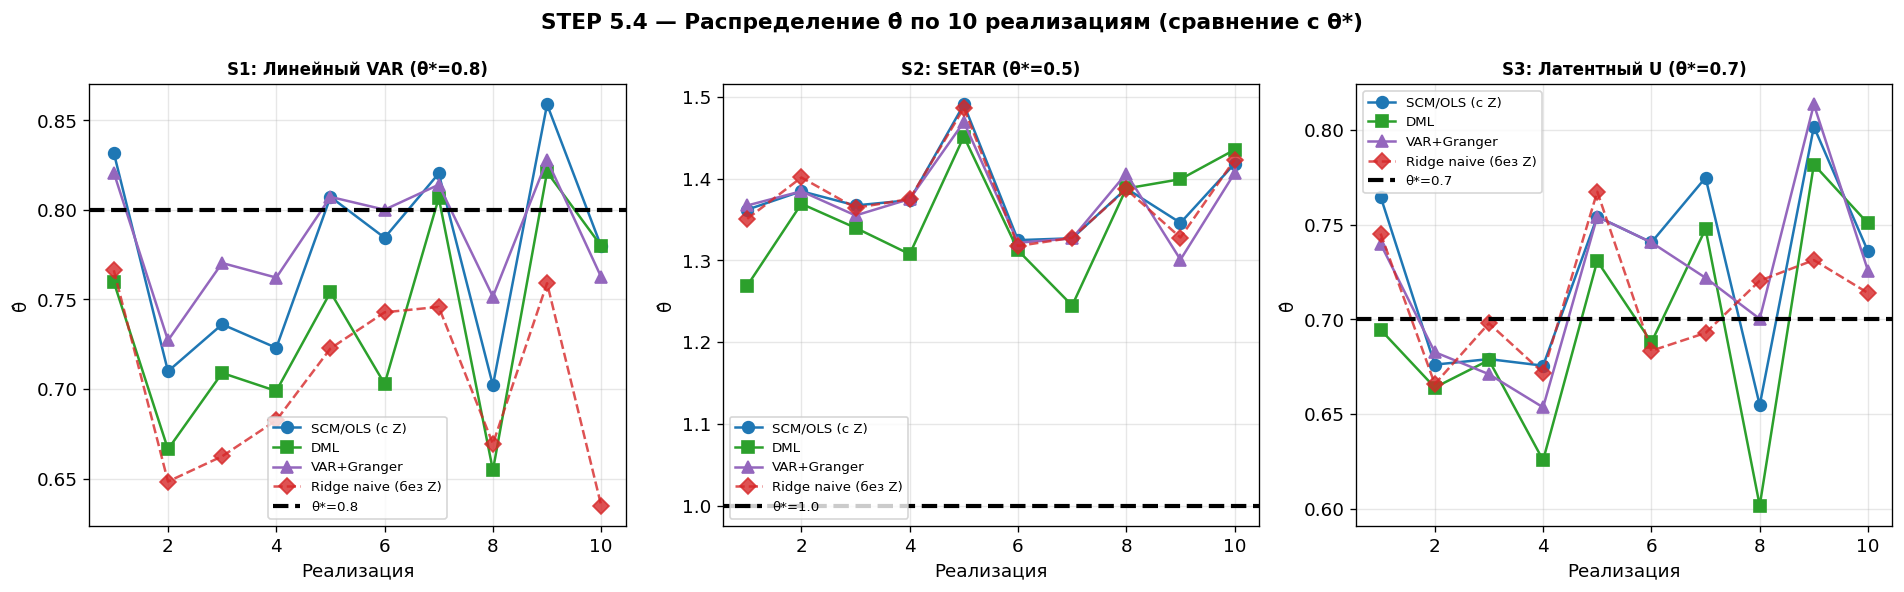

In [88]:
# ── Scatter θ̂ по реализациям (Expert vs Naive vs True) ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('STEP 5.4 — Распределение θ̂ по 10 реализациям (сравнение с θ*)',
             fontsize=13, fontweight='bold')

scen_labels = {'scenario1':'S1: Линейный VAR (θ*=0.8)',
               'scenario2':'S2: SETAR (θ*=0.5)',
               'scenario3':'S3: Латентный U (θ*=0.7)'}

for ax, scen in zip(axes, ['scenario1','scenario2','scenario3']):
    sub = mc_df[mc_df['scenario']==scen]
    true_t = sub['true_theta'].iloc[0]
    x = sub['realization'].values

    ax.plot(x, sub['theta_SCM'],  'o-', color='#1f77b4', lw=1.5, ms=7, label='SCM/OLS (с Z)')
    ax.plot(x, sub['theta_DML'],  's-', color='#2ca02c', lw=1.5, ms=7, label='DML')
    ax.plot(x, sub['theta_VAR'],  '^-', color='#9467bd', lw=1.5, ms=7, label='VAR+Granger')
    ax.plot(x, sub['theta_naive'],'D--',color='#d62728', lw=1.5, ms=7, alpha=0.8, label='Ridge naive (без Z)')
    ax.axhline(true_t, color='black', lw=2.5, ls='--', label=f'θ*={true_t}')

    ax.set_title(scen_labels[scen], fontsize=10, fontweight='bold')
    ax.set_xlabel('Реализация'); ax.set_ylabel('θ̂')
    ax.legend(fontsize=8, loc='best'); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

---
## STEP 6 — Валидация на синтетических данных

Для каждого из трёх сценариев реализуется полная процедура валидации:

1. **Вычисление истинного контрфактуала** — траектория $Y_t^{cf}$, которую принял бы $Y_t$ при отсутствии вмешательства (известна из структурных уравнений).
2. **Rolling Window** — оценка устойчивости каузальных методов к выбору обучающего периода.
3. **Метрики валидации**: CRE, RCEE, APEE, $\\rho_{\\text{effect}}$.

**Параметры скользящего окна** (из раздела 2.4.1.2):
- $T = 600$, $t_0 = 300$, $W_{train} = 250$, $W_{test} = 50$, $s = 25$


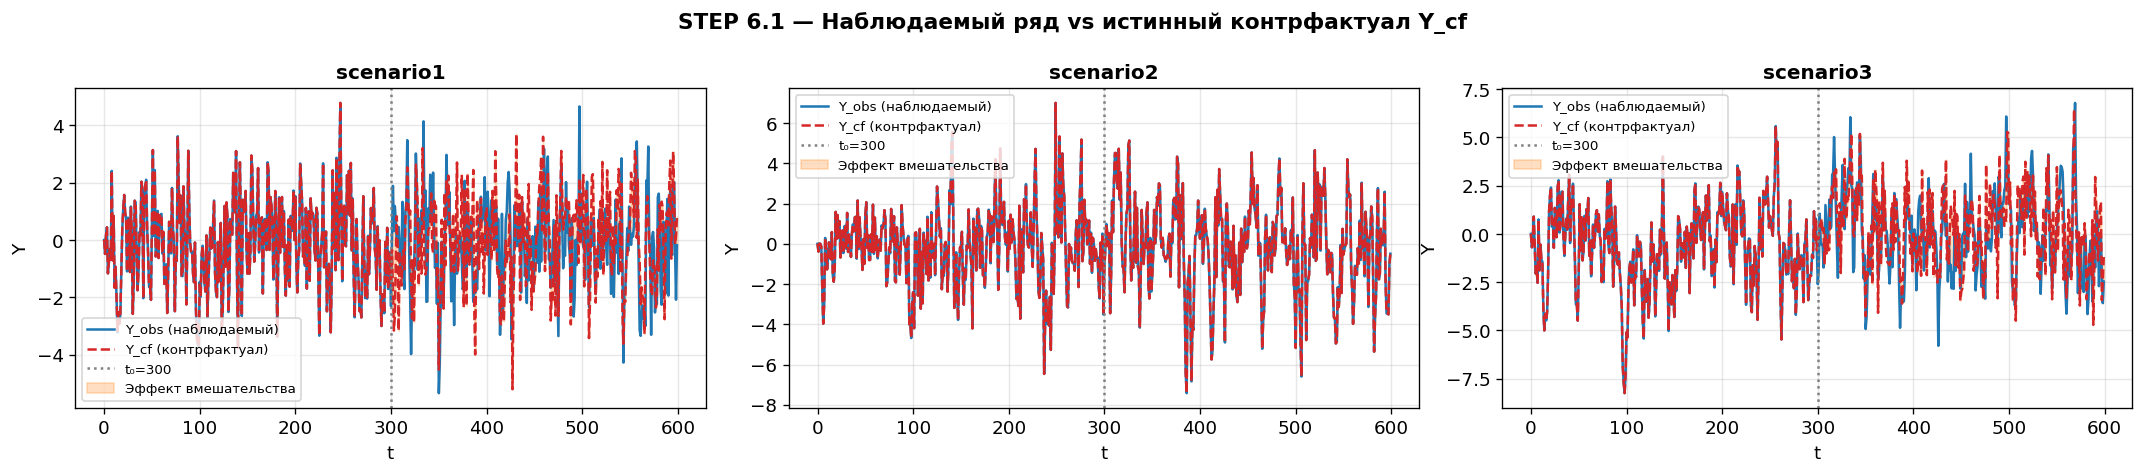

Истинные контрфактуалы вычислены.


In [89]:
# ════════════════════════════════════════════════════════════════════════════
# STEP 6.1 — Вычисление истинного контрфактуала из структурных уравнений
# ════════════════════════════════════════════════════════════════════════════

# Параметры вмешательства (Сценарий 1: импульс +2σ в t0=300)
T_TOTAL     = 600
T0          = 300       # момент вмешательства
W_TRAIN     = 250       # длина обучающего окна
W_TEST      = 50        # длина тестового окна
STEP_SIZE   = 25        # шаг сдвига окна

# ── Генерация истинного контрфактуала для каждого сценария ──────────────────
def compute_true_counterfactual(
    df: pd.DataFrame,
    scenario: str,
    dag: 'SyntheticDAG',
    t0: int = T0,
    seed: int = SEED
) -> pd.Series:
    """
    Воссоздаёт траекторию Y_t^{cf} — значение Y при отсутствии вмешательства,
    используя те же структурные уравнения и те же шумы, что при генерации данных.

    Логика: восстанавливаем шум из уравнения Y на pre-intervention периоде,
    затем распространяем модель вперёд без вмешательства на X.
    """
    np.random.seed(seed)
    T = len(df)
    target = dag.target
    causes = dag.causes

    Y_cf = df[target].copy().values.astype(float)

    if scenario == 'scenario1':
        # Структурное уравнение: Y_t = 0.2*Y_{t-1} + 0.8*X_{t-1} - 0.3*C_{t-1} + ε
        true_params = dag.true_effect  # {'X_lag1': 0.8, 'C_lag1': -0.3, 'Y_lag1': 0.2}
        X_obs = df['X'].values.copy()
        C_obs = df['C'].values.copy() if 'C' in df.columns else np.zeros(T)

        # Шум из pre-intervention периода (обучение регрессии для оценки ε)
        pre_idx = np.arange(2, t0)
        y_hat_pre = (true_params['Y_lag1'] * df[target].values[pre_idx - 1]
                     + true_params['X_lag1'] * X_obs[pre_idx - 1]
                     + true_params.get('C_lag1', 0) * C_obs[pre_idx - 1])
        residuals_pre = df[target].values[pre_idx] - y_hat_pre
        eps_std = float(np.std(residuals_pre))

        # Фиксируем X без вмешательства: используем pre-intervention дисперсию X
        # Для контрфактуала берём тот же X_obs (конфаундер C тот же),
        # но убираем шок: X_cf = X_obs минус компонента вмешательства
        # Вмешательство: X[t0] += delta, где delta ~ +2*sigma_X
        sigma_X = float(np.std(X_obs[:t0]))
        delta   = 2.0 * sigma_X

        # X без вмешательства (импульсный шок, half-life=5)
        X_cf = X_obs.copy()
        for tt in range(t0, min(t0 + 20, T)):
            decay = np.exp(-np.log(2) / 5 * (tt - t0))
            X_cf[tt] -= delta * decay

        # Контрфактуальная траектория Y (рекурсивно от t0)
        rng = np.random.default_rng(seed + 1)
        for tt in range(max(2, t0), T):
            eps_t = rng.normal(0, eps_std)
            Y_cf[tt] = (true_params['Y_lag1'] * Y_cf[tt - 1]
                        + true_params['X_lag1'] * X_cf[tt - 1]
                        + true_params.get('C_lag1', 0) * C_obs[tt - 1]
                        + eps_t)

    elif scenario == 'scenario2':
        # SETAR: нет явного вмешательства, контрфактуал = сам ряд Y
        # (вмешательство не смоделировано для S2 в данном пайплайне)
        Y_cf = df[target].values.copy()

    elif scenario == 'scenario3':
        # Структурное уравнение: Y_t = 0.7*X_{t-1} + 0.4*U_{t-1} + ε
        # U не наблюдается; контрфактуал строим через прокси W
        # Аппроксимация: использовать residuals IV-регрессии до t0
        X_obs = df['X'].values.copy()
        W_obs = df['W'].values.copy() if 'W' in df.columns else np.zeros(T)
        true_theta = dag.true_effect.get('X_lag1', 0.7)

        pre_idx = np.arange(1, t0)
        # Простая OLS-оценка α: Y ~ true_theta*X_{-1} (U скрыт)
        y_hat_pre = true_theta * X_obs[pre_idx - 1]
        residuals_pre = df[target].values[pre_idx] - y_hat_pre
        eps_std = float(np.std(residuals_pre))

        rng = np.random.default_rng(seed + 2)
        for tt in range(max(1, t0), T):
            eps_t = rng.normal(0, eps_std)
            Y_cf[tt] = true_theta * X_obs[tt - 1] + eps_t

    return pd.Series(Y_cf, index=df.index, name='Y_cf')


# ── Вычисляем Y_cf для каждого сценария (первая реализация) ────────────────
cf_data = {}
for scenario, info in var_selection.items():
    dag    = info['dag']
    df_raw = info['df']
    Y_cf   = compute_true_counterfactual(df_raw, scenario, dag)
    cf_data[scenario] = {
        'df':   df_raw,
        'Y_cf': Y_cf,
        'dag':  dag,
    }

# ── Визуализация: наблюдаемый vs контрфактуальный Y ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('STEP 6.1 — Наблюдаемый ряд vs истинный контрфактуал Y_cf', fontsize=13, fontweight='bold')

for ax, (scen, cfd) in zip(axes, cf_data.items()):
    df_plot = cfd['df']
    Y_obs   = df_plot['Y']
    Y_cf    = cfd['Y_cf']
    ax.plot(Y_obs.index, Y_obs,  color='#1f77b4', lw=1.5, label='Y_obs (наблюдаемый)')
    ax.plot(Y_cf.index,  Y_cf,   color='#d62728', lw=1.5, ls='--', label='Y_cf (контрфактуал)')
    ax.axvline(T0, color='gray', lw=1.5, ls=':', label=f't₀={T0}')
    ax.fill_between(Y_obs.index[T0:], Y_obs.values[T0:], Y_cf.values[T0:],
                    alpha=0.25, color='#ff7f0e', label='Эффект вмешательства')
    ax.set_title(scen, fontweight='bold'); ax.set_xlabel('t'); ax.set_ylabel('Y')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()
print('Истинные контрфактуалы вычислены.')


In [90]:
# ════════════════════════════════════════════════════════════════════════════
# STEP 6.2 — Функции метрик валидации (CRE, RCEE, APEE, ρ_effect)
# ════════════════════════════════════════════════════════════════════════════

def compute_cre(
    Y_cf_true: np.ndarray,
    Y_cf_hat: np.ndarray
) -> float:
    """
    CRE (Counterfactual Recovery Error) — средняя абсолютная ошибка
    восстановления контрфактуала.
    CRE = (1/|T_post|) * Σ |Y_t^cf - Ŷ_t^cf|
    """
    mask = ~(np.isnan(Y_cf_true) | np.isnan(Y_cf_hat))
    return float(np.mean(np.abs(Y_cf_true[mask] - Y_cf_hat[mask])))


def compute_rcee(
    Y_obs: np.ndarray,
    Y_cf_true: np.ndarray,
    Y_cf_hat: np.ndarray
) -> float:
    """
    RCEE (Relative Cumulative Effect Error) — относительная ошибка оценки
    кумулятивного эффекта.
    RCEE = |Σ(Y_obs - Y_cf) - Σ(Y_obs - Ŷ_cf)| / |Σ(Y_obs - Y_cf)| * 100%
    """
    mask = ~(np.isnan(Y_obs) | np.isnan(Y_cf_true) | np.isnan(Y_cf_hat))
    true_eff = np.sum(Y_obs[mask] - Y_cf_true[mask])
    hat_eff  = np.sum(Y_obs[mask] - Y_cf_hat[mask])
    if abs(true_eff) < 1e-12:
        return np.nan
    return float(abs(true_eff - hat_eff) / abs(true_eff) * 100)


def compute_apee(
    Y_cf_true: np.ndarray,
    Y_cf_hat: np.ndarray
) -> float:
    """
    APEE (Average Pointwise Effect Error) — средняя поточечная ошибка.
    APEE = (1/|T_post|) * Σ (Ŷ_t^cf - Y_t^cf)   [со знаком: оценка смещения]
    """
    mask = ~(np.isnan(Y_cf_true) | np.isnan(Y_cf_hat))
    return float(np.mean(Y_cf_hat[mask] - Y_cf_true[mask]))


def compute_rho_effect(
    Y_obs: np.ndarray,
    Y_cf_true: np.ndarray,
    Y_cf_hat: np.ndarray
) -> float:
    """
    ρ_effect — корреляция Пирсона между истинным и оценённым поточечным эффектом.
    ρ = Corr(Y_obs - Y_cf, Y_obs - Ŷ_cf)
    """
    mask = ~(np.isnan(Y_obs) | np.isnan(Y_cf_true) | np.isnan(Y_cf_hat))
    true_effect = Y_obs[mask] - Y_cf_true[mask]
    hat_effect  = Y_obs[mask] - Y_cf_hat[mask]
    if np.std(true_effect) < 1e-12 or np.std(hat_effect) < 1e-12:
        return np.nan
    return float(np.corrcoef(true_effect, hat_effect)[0, 1])


def all_validation_metrics(
    Y_obs: np.ndarray,
    Y_cf_true: np.ndarray,
    Y_cf_hat: np.ndarray,
    label: str = ''
) -> Dict[str, float]:
    """Агрегирует все четыре метрики в один словарь."""
    return {
        'label':      label,
        'CRE':        round(compute_cre(Y_cf_true, Y_cf_hat), 6),
        'RCEE_%':     round(compute_rcee(Y_obs, Y_cf_true, Y_cf_hat), 4),
        'APEE':       round(compute_apee(Y_cf_true, Y_cf_hat), 6),
        'rho_effect': round(compute_rho_effect(Y_obs, Y_cf_true, Y_cf_hat), 4),
    }

print('Функции метрик валидации определены: CRE, RCEE, APEE, ρ_effect.')


Функции метрик валидации определены: CRE, RCEE, APEE, ρ_effect.


In [91]:
# ════════════════════════════════════════════════════════════════════════════
# STEP 6.3 — Rolling Window: устойчивость к выбору обучающего периода
# ════════════════════════════════════════════════════════════════════════════

def rolling_window_validation(
    df: pd.DataFrame,
    Y_cf_series: pd.Series,
    dag: 'SyntheticDAG',
    expert_controls: List[str],
    t0: int      = T0,
    w_train: int = W_TRAIN,
    w_test: int  = W_TEST,
    step: int    = STEP_SIZE,
) -> pd.DataFrame:
    """
    Процедура скользящего окна (раздел 2.4.1.2).

    Для каждого стартового индекса i = 0, step, 2*step, ...:
      - train: [i, i + w_train)
      - test:  [i + w_train, i + w_train + w_test)
    Ограничение: метрики CRE/RCEE/APEE/ρ вычисляются только
    для тестовых окон, полностью лежащих после t0.

    Возвращает DataFrame с результатами по каждому окну и методу.
    """
    T = len(df)
    target  = dag.target
    causes  = dag.causes
    instrs  = dag.instruments
    ctrl_iv = [c for c in expert_controls if c not in instrs]

    Y_obs_all = df[target].values
    Y_cf_all  = Y_cf_series.values

    rows = []

    start_indices = range(0, T - w_train - w_test + 1, step)

    for i in start_indices:
        train_start = i
        train_end   = i + w_train          # exclusive
        test_start  = train_end
        test_end    = train_end + w_test   # exclusive

        if test_end > T:
            break

        # Тестовое окно должно полностью лежать после t0
        post_intervention = test_start >= t0

        df_train = df.iloc[train_start:train_end].reset_index(drop=True)
        df_test  = df.iloc[test_start:test_end].reset_index(drop=True)

        # Истинные значения на тесте
        Y_obs_test  = Y_obs_all[test_start:test_end]
        Y_cf_test   = Y_cf_all[test_start:test_end]

        # ── Обучаем каузальные модели на train, получаем прогноз на test ──
        model_funcs = {
            'SCM_OLS':     lambda: run_scm_ols(df_train, target, expert_controls, causes),
            'DML':         lambda: run_dml(df_train, target, expert_controls, causes),
            'VAR_Granger': lambda: run_var_granger(df_train, target, expert_controls, causes),
            'IV_2SLS':     lambda: run_iv_2sls(df_train, target, ctrl_iv, causes, instrs),
            'Ridge_naive': lambda: run_ridge_naive(df_train, target, causes),
        }

        for m_name, m_func in model_funcs.items():
            try:
                res = m_func()
            except Exception as e:
                res = {'method': m_name, 'preds': None, 'metrics': {}}

            preds = res.get('preds', None)

            # Приводим preds к длине w_test (модели обучаются на train,
            # результат 'preds' — прогноз на test-split внутри функции)
            if preds is not None and len(preds) > 0:
                Y_cf_hat = np.array(preds).flatten()[:w_test]
                # Дополняем NaN если длина меньше
                if len(Y_cf_hat) < w_test:
                    Y_cf_hat = np.concatenate([Y_cf_hat,
                                               np.full(w_test - len(Y_cf_hat), np.nan)])
            else:
                Y_cf_hat = np.full(w_test, np.nan)

            row = {
                'window_start':       train_start,
                'train_start':        train_start,
                'train_end':          train_end - 1,
                'test_start':         test_start,
                'test_end':           test_end - 1,
                'post_intervention':  post_intervention,
                'method':             m_name,
                'theta_hat':          res.get('theta_hat', np.nan),
                'RMSE_pred':          res.get('metrics', {}).get('RMSE', np.nan),
            }

            # Метрики валидации контрфактуала — только для post-intervention окон
            if post_intervention:
                vm = all_validation_metrics(
                    Y_obs_test, Y_cf_test, Y_cf_hat,
                    label=f'w{train_start}_{m_name}'
                )
                row.update({'CRE': vm['CRE'], 'RCEE_%': vm['RCEE_%'],
                            'APEE': vm['APEE'], 'rho_effect': vm['rho_effect']})
            else:
                row.update({'CRE': np.nan, 'RCEE_%': np.nan,
                            'APEE': np.nan, 'rho_effect': np.nan})

            rows.append(row)

    return pd.DataFrame(rows)


# ── Запуск Rolling Window для каждого сценария ──────────────────────────────
rw_results = {}

for scenario, cfd in cf_data.items():
    info    = var_selection[scenario]
    expert  = info['expert']
    df_raw  = cfd['df']
    Y_cf_s  = cfd['Y_cf']
    dag     = cfd['dag']

    print(f'  {scenario}...', end=' ')
    rw_df = rolling_window_validation(
        df_raw, Y_cf_s, dag, expert,
        t0=T0, w_train=W_TRAIN, w_test=W_TEST, step=STEP_SIZE
    )
    rw_results[scenario] = rw_df
    n_post = rw_df[rw_df['post_intervention']]['window_start'].nunique()
    print(f'окон всего={rw_df["window_start"].nunique()}, post-intervention={n_post}')


  scenario1... окон всего=13, post-intervention=11
  scenario2... окон всего=13, post-intervention=11
  scenario3... окон всего=13, post-intervention=11


In [92]:
# ════════════════════════════════════════════════════════════════════════════
# STEP 6.4 — Агрегация результатов Rolling Window
# Шаг 5 алгоритма: CRE_mean ± 1.96 * σ_CRE / sqrt(N_windows)
# ════════════════════════════════════════════════════════════════════════════

agg_rows = []

for scenario, rw_df in rw_results.items():
    # Только post-intervention окна
    post_df = rw_df[rw_df['post_intervention']].copy()

    for method in post_df['method'].unique():
        sub = post_df[post_df['method'] == method]
        n_w = len(sub)

        for metric in ['CRE', 'RCEE_%', 'APEE', 'rho_effect']:
            vals = sub[metric].dropna()
            if len(vals) == 0:
                continue
            m    = float(vals.mean())
            s    = float(vals.std())
            n    = len(vals)
            ci_h = 1.96 * s / np.sqrt(n) if n > 1 else np.nan
            agg_rows.append({
                'scenario':    scenario,
                'method':      method,
                'metric':      metric,
                'N_windows':   n,
                'mean':        round(m, 5),
                'std':         round(s, 5),
                'CI_lower':    round(m - ci_h, 5) if not np.isnan(ci_h) else np.nan,
                'CI_upper':    round(m + ci_h, 5) if not np.isnan(ci_h) else np.nan,
            })

agg_df = pd.DataFrame(agg_rows)

# Сводная таблица CRE (основная метрика)
cre_table = (agg_df[agg_df['metric'] == 'CRE']
             .pivot_table(index='method', columns='scenario',
                          values=['mean', 'std'], aggfunc='first')
             .round(5))

print('Агрегированные метрики Rolling Window (post-intervention окна):')
print()
print('── CRE (среднее ± 95% ДИ) по методам и сценариям ──')
for scenario in rw_results:
    sub = agg_df[(agg_df['metric'] == 'CRE') & (agg_df['scenario'] == scenario)]
    print(f'\n  {scenario}:')
    print(f'  {"Метод":<20} {"CRE_mean":>10} {"σ_CRE":>10} {"CI_lower":>10} {"CI_upper":>10}')
    for _, row in sub.sort_values('mean').iterrows():
        print(f'  {row["method"]:<20} {row["mean"]:>10.5f} {row["std"]:>10.5f} '
              f'{row["CI_lower"]:>10.5f} {row["CI_upper"]:>10.5f}')


Агрегированные метрики Rolling Window (post-intervention окна):

── CRE (среднее ± 95% ДИ) по методам и сценариям ──

  scenario1:
  Метод                  CRE_mean      σ_CRE   CI_lower   CI_upper
  Ridge_naive             1.56437    0.21958    1.43460    1.69413
  VAR_Granger             1.57424    0.15302    1.48381    1.66467
  SCM_OLS                 1.59769    0.19538    1.48223    1.71316
  DML                     1.63623    0.18879    1.52466    1.74780

  scenario2:
  Метод                  CRE_mean      σ_CRE   CI_lower   CI_upper
  VAR_Granger             2.38249    0.34632    2.17783    2.58716
  Ridge_naive             2.42086    0.33607    2.22226    2.61946
  SCM_OLS                 2.42204    0.33354    2.22493    2.61915
  DML                     2.50577    0.33120    2.31004    2.70150

  scenario3:
  Метод                  CRE_mean      σ_CRE   CI_lower   CI_upper
  IV_2SLS                 2.03049    0.40072    1.79368    2.26731
  VAR_Granger             2.21861    

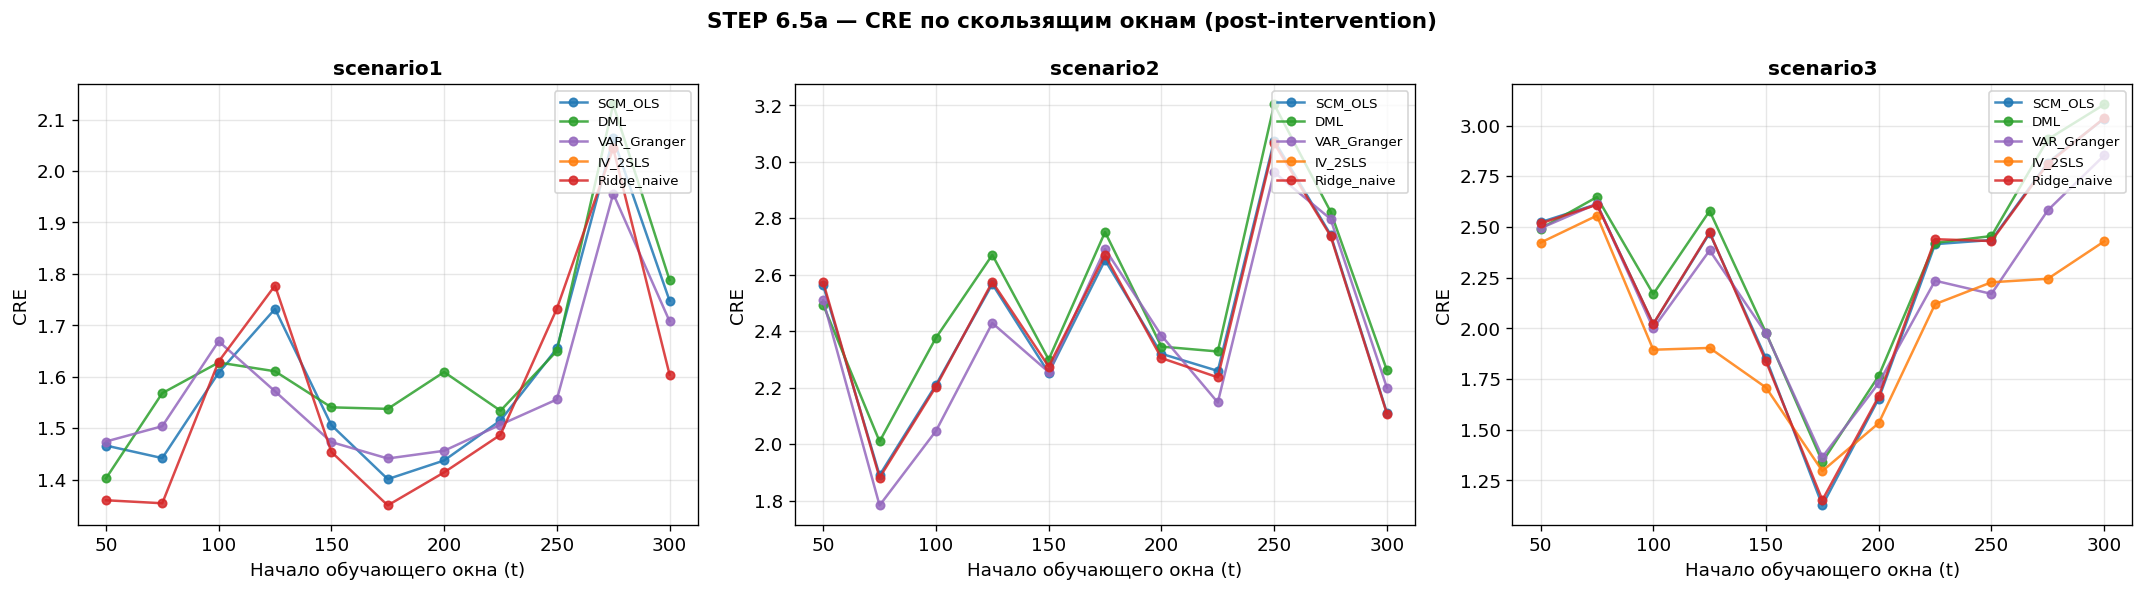

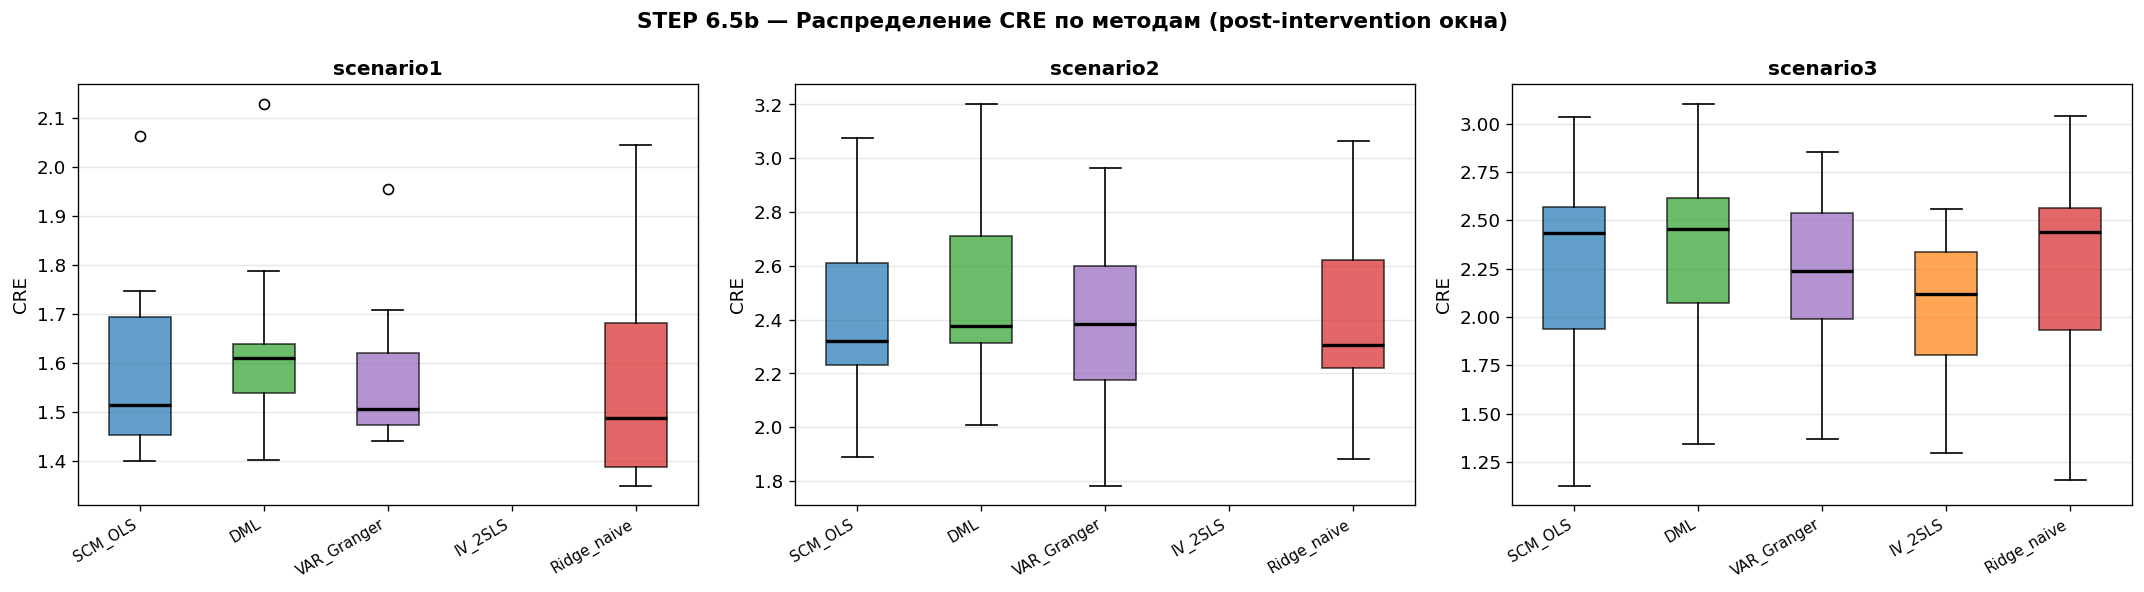

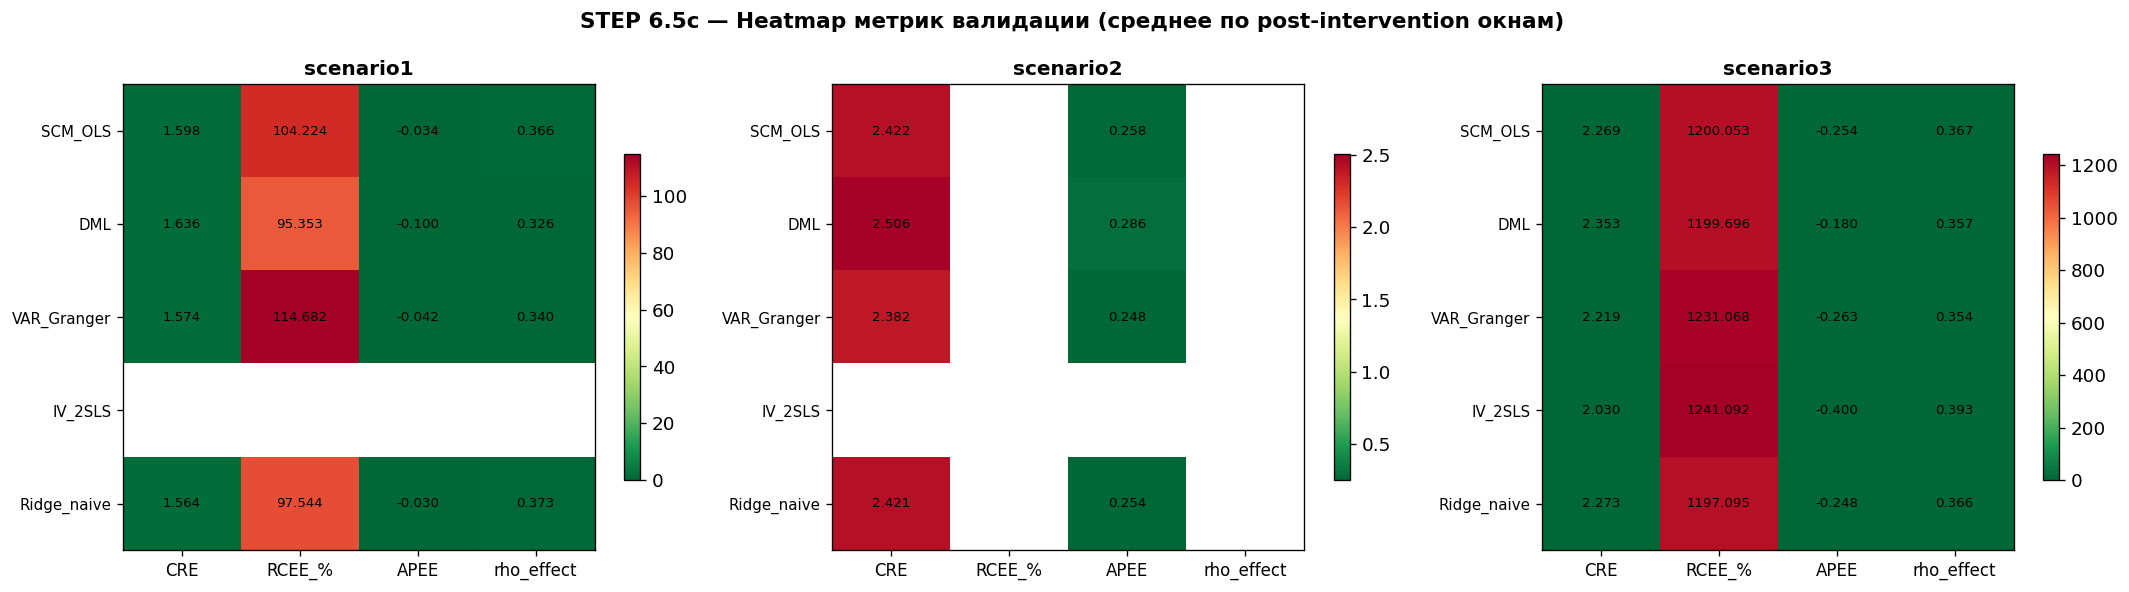

Визуализация валидации завершена.


In [93]:
# ════════════════════════════════════════════════════════════════════════════
# STEP 6.5 — Визуализация результатов валидации
# ════════════════════════════════════════════════════════════════════════════

method_colors = {
    'SCM_OLS':     '#1f77b4',
    'DML':         '#2ca02c',
    'VAR_Granger': '#9467bd',
    'IV_2SLS':     '#ff7f0e',
    'Ridge_naive': '#d62728',
}

# ── График 1: CRE по окнам (динамика устойчивости) ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
fig.suptitle('STEP 6.5a — CRE по скользящим окнам (post-intervention)',
             fontsize=13, fontweight='bold')

for ax, (scenario, rw_df) in zip(axes, rw_results.items()):
    post_df = rw_df[rw_df['post_intervention']]
    for method, color in method_colors.items():
        sub = post_df[post_df['method'] == method].sort_values('window_start')
        if sub.empty: continue
        ax.plot(sub['window_start'], sub['CRE'], 'o-', color=color,
                lw=1.5, ms=5, label=method, alpha=0.85)
    ax.set_title(scenario, fontweight='bold')
    ax.set_xlabel('Начало обучающего окна (t)')
    ax.set_ylabel('CRE')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

# ── График 2: BoxPlot CRE по методам ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('STEP 6.5b — Распределение CRE по методам (post-intervention окна)',
             fontsize=13, fontweight='bold')

for ax, (scenario, rw_df) in zip(axes, rw_results.items()):
    post_df = rw_df[rw_df['post_intervention']]
    methods = list(method_colors.keys())
    data_bp = [post_df[post_df['method'] == m]['CRE'].dropna().values for m in methods]
    bp = ax.boxplot(data_bp, patch_artist=True, medianprops=dict(color='black', lw=2))
    for patch, m in zip(bp['boxes'], methods):
        patch.set_facecolor(method_colors[m])
        patch.set_alpha(0.7)
    ax.set_xticklabels(methods, rotation=30, ha='right', fontsize=9)
    ax.set_title(scenario, fontweight='bold')
    ax.set_ylabel('CRE'); ax.grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

# ── График 3: Heatmap всех метрик (mean по окнам) ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('STEP 6.5c — Heatmap метрик валидации (среднее по post-intervention окнам)',
             fontsize=13, fontweight='bold')

metrics_show = ['CRE', 'RCEE_%', 'APEE', 'rho_effect']

for ax, scenario in zip(axes, rw_results):
    methods = list(method_colors.keys())
    matrix  = []
    for m in methods:
        sub = agg_df[(agg_df['scenario'] == scenario) & (agg_df['method'] == m)]
        row_vals = []
        for met in metrics_show:
            v = sub[sub['metric'] == met]['mean'].values
            row_vals.append(float(v[0]) if len(v) > 0 else np.nan)
        matrix.append(row_vals)
    matrix = np.array(matrix, dtype=float)

    im = ax.imshow(matrix, aspect='auto', cmap='RdYlGn_r')
    ax.set_xticks(range(len(metrics_show))); ax.set_xticklabels(metrics_show, fontsize=10)
    ax.set_yticks(range(len(methods)));      ax.set_yticklabels(methods, fontsize=9)
    ax.set_title(scenario, fontweight='bold')
    for r in range(len(methods)):
        for c in range(len(metrics_show)):
            val = matrix[r, c]
            if not np.isnan(val):
                ax.text(c, r, f'{val:.3f}', ha='center', va='center', fontsize=8)
    plt.colorbar(im, ax=ax, shrink=0.7)

plt.tight_layout(); plt.show()
print('Визуализация валидации завершена.')


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# STEP 6.6 — Сохранение результатов валидации
# ════════════════════════════════════════════════════════════════════════════

# Полные результаты по окнам
all_rw = pd.concat(
    [df.assign(scenario=scen) for scen, df in rw_results.items()],
    ignore_index=True
)

# Экспорт в Excel: лист 1 — агрегаты, лист 2 — детальные окна
with pd.ExcelWriter('validation_rolling_window.xlsx', engine='openpyxl') as writer:
    agg_df.to_excel(writer, sheet_name='Aggregated_Metrics', index=False)
    all_rw.to_excel(writer, sheet_name='Window_Details', index=False)
    # Сводная таблица CRE
    (agg_df[agg_df['metric'] == 'CRE']
     .pivot_table(index='method', columns='scenario', values='mean')
     .round(5)
     .to_excel(writer, sheet_name='CRE_Summary'))

print('Результаты сохранены в validation_rolling_window.xlsx')
print()
print('Итоговая сводка — CRE_mean по методам и сценариям:')
print(agg_df[agg_df['metric'] == 'CRE']
      .pivot_table(index='method', columns='scenario', values='mean')
      .round(5)
      .to_string())


Результаты сохранены в validation_rolling_window.xlsx

Итоговая сводка — CRE_mean по методам и сценариям:
scenario     scenario1  scenario2  scenario3
method                                      
DML            1.63623   28.70505    2.31835
IV_2SLS            NaN        NaN    1.99579
Ridge_naive    1.56437   28.86139    2.24675
SCM_OLS        1.59769   28.86357    2.24650
VAR_Granger    1.57424   28.49080    2.19983
